In [15]:
import os
import numpy as np
import random
import collections
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DATA_DIR = '/content/drive/MyDrive/Asg2/processed_data'
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

CHECKPOINTS_DIR = '/content/drive/MyDrive/Asg2/checkpoints'
RESULTS_DIR = '/content/drive/MyDrive//Asg2/results'
# os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
# os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 128
EPOCHS = 40
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {DEVICE}")
print(f"Checkpoints dir: {CHECKPOINTS_DIR}")
print(f"Results dir: {RESULTS_DIR}")

Using device: cuda
Checkpoints dir: /content/drive/MyDrive/Asg2/checkpoints
Results dir: /content/drive/MyDrive//Asg2/results


In [18]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [19]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from /content/drive/MyDrive/Asg2/processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [20]:
data_iter = iter(train_loader)
batch = next(data_iter)

# A batch usually consists of features (images) and labels
# The structure depends on how your Dataset.__getitem__ is implemented
if isinstance(batch, list) or isinstance(batch, tuple):
    images, labels = batch
    print(f"Images shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
else:
    # If your dataloader returns a single item
    print(f"Batch shape: {batch.shape}")




Images shape: torch.Size([128, 784])
Labels shape: torch.Size([128])


In [21]:
# ==========================================
# 4. NORMALIZATION STATS

# Uses the same full_train_dataset created above
DATA_MEAN = full_train_dataset.x.mean().item()
DATA_STD = full_train_dataset.x.std().item() + 1e-8
print(f"DATA_MEAN={DATA_MEAN:.6f}, DATA_STD={DATA_STD:.6f}")

def normalize_batch(images):
    return (images.float() - DATA_MEAN) / DATA_STD

DATA_MEAN=0.188342, DATA_STD=0.338611


In [22]:
# ==========================================
# 5. PATCHMLP_v2 MODEL DEFINITION
# ==========================================

import torch.nn.functional as F

class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = float(drop_prob)

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1.0 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = x.new_empty(shape).bernoulli_(keep_prob)
        return x * random_tensor / keep_prob


class GatedMLP(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.0, act="silu"):
        super().__init__()
        self.fc1 = nn.Linear(dim, 2 * hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.drop = nn.Dropout(dropout)
        self.act = act

    def _act(self, x):
        if self.act == "silu":
            return F.silu(x)
        if self.act == "gelu":
            return F.gelu(x)
        raise ValueError("act must be 'silu' or 'gelu'")

    def forward(self, x):
        x = self.fc1(x)
        a, b = x.chunk(2, dim=-1)
        x = a * self._act(b)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class MixerBlock_v5_NoConv(nn.Module):
    def __init__(
        self,
        num_tokens,
        dim,
        token_mlp_dim,
        channel_mlp_dim,
        dropout=0.08,
        drop_path=0.10,
        gate_act="silu",
    ):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.token_mlp = nn.Sequential(
            nn.Linear(num_tokens, token_mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(token_mlp_dim, num_tokens),
            nn.Dropout(dropout),
        )
        self.dp1 = DropPath(drop_path)

        self.norm2 = nn.LayerNorm(dim)
        self.channel_mlp = GatedMLP(dim, channel_mlp_dim, dropout=dropout, act=gate_act)
        self.dp2 = DropPath(drop_path)

    def forward(self, x):
        y = self.norm1(x)
        y = y.transpose(1, 2)
        y = self.token_mlp(y)
        y = y.transpose(1, 2)
        x = x + self.dp1(y)

        y = self.norm2(x)
        y = self.channel_mlp(y)
        x = x + self.dp2(y)
        return x


class PatchMLP_v2(nn.Module):
    def __init__(
        self,
        num_classes=15,
        img_size=28,
        patch_size=4,
        in_chans=1,
        embed_dim=192,
        depth=8,
        token_mlp_dim=128,
        channel_mlp_dim=384,
        dropout=0.08,
        drop_path_rate=0.12,
        gate_act="silu",
        use_cls_token=True,
    ):
        super().__init__()
        assert img_size % patch_size == 0, "patch_size must divide img_size"

        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.use_cls_token = use_cls_token

        n = img_size // patch_size
        num_patches = n * n
        patch_dim = in_chans * patch_size * patch_size

        self.num_tokens = num_patches + (1 if use_cls_token else 0)

        self.patch_embed = nn.Linear(patch_dim, embed_dim)

        if use_cls_token:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
            nn.init.normal_(self.cls_token, mean=0.0, std=0.02)
        else:
            self.cls_token = None

        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens, embed_dim))
        nn.init.normal_(self.pos_embed, mean=0.0, std=0.02)

        self.emb_norm = nn.LayerNorm(embed_dim)
        self.emb_drop = nn.Dropout(dropout)

        drop_path_values = torch.linspace(0, drop_path_rate, steps=depth).tolist()
        self.blocks = nn.ModuleList([
            MixerBlock_v5_NoConv(
                num_tokens=self.num_tokens,
                dim=embed_dim,
                token_mlp_dim=token_mlp_dim,
                channel_mlp_dim=channel_mlp_dim,
                dropout=dropout,
                drop_path=drop_path_values[i],
                gate_act=gate_act,
            )
            for i in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes),
        )

    def _to_image(self, x):
        if x.dim() == 2:
            batch_size = x.size(0)
            x = x.view(batch_size, 1, self.img_size, self.img_size)
        elif x.dim() == 3:
            x = x.unsqueeze(1)
        elif x.dim() != 4:
            raise ValueError(f"Unsupported input shape: {tuple(x.shape)}")

        if x.size(1) != self.in_chans:
            raise ValueError(f"Expected {self.in_chans} channel(s), got {x.size(1)}")
        return x

    def _patchify(self, x):
        batch_size, channels, height, width = x.shape
        patch = self.patch_size
        x = x.view(batch_size, channels, height // patch, patch, width // patch, patch)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()
        x = x.view(batch_size, (height // patch) * (width // patch), channels * patch * patch)
        return x

    def forward(self, x):
        if x.dtype not in (torch.float32, torch.float16, torch.bfloat16):
            x = x.float()

        x = self._to_image(x)
        x = self._patchify(x)
        x = self.patch_embed(x)

        if self.use_cls_token:
            cls_token = self.cls_token.expand(x.size(0), -1, -1)
            x = torch.cat([cls_token, x], dim=1)

        x = self.emb_norm(x + self.pos_embed)
        x = self.emb_drop(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        x = x[:, 0] if self.use_cls_token else x.mean(dim=1)
        return self.head(x)

In [23]:
# ==========================================
# 6. SHARED TRAINING + DIAGNOSTICS UTILITIES
# ==========================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = normalize_batch(images).to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def train_one_epoch(model, train_loader, optimizer, criterion, device, scheduler=None, grad_clip=5.0):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    grad_sums = collections.defaultdict(float)
    grad_counts = collections.defaultdict(int)

    is_onecycle = isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR)

    for images, labels in train_loader:
        images = normalize_batch(images).to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

        for name, param in model.named_parameters():
            if param.grad is not None and param.requires_grad:
                norm_val = param.grad.detach().norm(2).item()
                grad_sums[name] += norm_val
                grad_counts[name] += 1

        optimizer.step()

        if scheduler is not None and is_onecycle:
            scheduler.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)

    avg_grad_norms = {k: grad_sums[k] / max(1, grad_counts[k]) for k in grad_sums}
    return total_loss / total_samples, total_correct / total_samples, avg_grad_norms


def fit_model(
    model,
    model_name,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    scheduler=None,
    epochs=EPOCHS,
    grad_clip=5.0,
    verbose=True,
    save_best_path=None,
    keep_best_in_memory=True,
    best_metric="acc",
):
    history = {
        "model_name": model_name,
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
        "grad_norms": [],
    }

    best_val_acc, best_val_loss, best_epoch = -1.0, float("inf"), -1
    best_state = None

    is_onecycle = isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR)
    is_plateau = isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau)

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, grad_norms = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            scheduler=scheduler,
            grad_clip=grad_clip,
        )
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)

        if scheduler is not None:
            if is_plateau:
                scheduler.step(val_acc)
            elif not is_onecycle:
                scheduler.step()

        lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(lr)
        history["grad_norms"].append(grad_norms)

        improved = (val_acc > best_val_acc) if best_metric == "acc" else (val_loss < best_val_loss)
        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch

            if save_best_path is not None:
                torch.save(model.state_dict(), save_best_path)

            if keep_best_in_memory:
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            print(
                f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
                f"Train: loss {train_loss:.4f}, acc {train_acc:.4f} | "
                f"Val: loss {val_loss:.4f}, acc {val_acc:.4f} | "
                f"LR: {lr:.6f} | Best Val Acc: {best_val_acc:.4f} (ep {best_epoch})"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    history["best_val_acc"] = best_val_acc
    history["best_val_loss"] = best_val_loss
    history["best_epoch"] = best_epoch

    print(f"[{model_name}] Best val acc={best_val_acc:.4f} at epoch {best_epoch}")
    return history


@torch.no_grad()
def get_predictions_and_labels(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = normalize_batch(images).to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    return np.concatenate(all_preds), np.concatenate(all_labels)


def plot_training_diagnostics(history, top_k_layers=10):
    epochs_axis = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs_axis, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_axis, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss vs Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_axis, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs_axis, history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy vs Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs_axis, history["lr"], label="Learning Rate")
    axes[2].set_title("Learning Rate vs Epoch")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("LR")
    axes[2].set_yscale("log")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    grad_norms = history.get("grad_norms", [])
    if not grad_norms:
        return

    layer_names = sorted({name for layer_dict in grad_norms for name in layer_dict.keys()})
    means = {}
    for name in layer_names:
        values = [layer_dict.get(name, np.nan) for layer_dict in grad_norms]
        values = [value for value in values if not np.isnan(value)]
        means[name] = float(np.mean(values)) if values else 0.0

    top_layers = sorted(means, key=means.get, reverse=True)[:top_k_layers]

    plt.figure(figsize=(12, 6))
    for name in top_layers:
        values = [layer_dict.get(name, np.nan) for layer_dict in grad_norms]
        plt.plot(epochs_axis, values, label=name, alpha=0.85)

    plt.title(f"Gradient Norm Traverse (Top {top_k_layers} layers)")
    plt.xlabel("Epoch")
    plt.ylabel("Avg Grad L2 Norm")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


def plot_confusion_and_classwise(model, val_loader, classes, device):
    val_preds, val_labels = get_predictions_and_labels(model, val_loader, device)
    val_acc = (val_preds == val_labels).mean()
    print(f"Validation accuracy: {val_acc:.4f}")

    cm = confusion_matrix(val_labels, val_preds)

    plt.figure(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
    plt.title("Confusion Matrix (Validation Set)")
    plt.show()

    class_totals = cm.sum(axis=1) + 1e-12
    class_acc = cm.diagonal() / class_totals
    print("\nClasswise accuracy (low -> high):")
    for idx in np.argsort(class_acc):
        print(f"{classes[idx]:15s} accuracy: {class_acc[idx]:.3f}")

    return cm, class_acc


def run_diagnostics(model, history, val_loader, classes, device, top_k_grad_layers=10):
    plot_training_diagnostics(history, top_k_layers=top_k_grad_layers)
    cm, class_acc = plot_confusion_and_classwise(model, val_loader, classes, device)
    return cm, class_acc


def run_patchmlp_experiment(
    tag,
    model_kwargs,
    max_lr=4e-3,
    weight_decay=2e-4,
    label_smoothing=0.05,
    grad_clip=5.0,
    epochs=EPOCHS,
    run_live_diagnostics=True,
    top_k_grad_layers=10,
):
    print("\n" + "=" * 80)
    print(f"Running {tag}")
    print("=" * 80)

    model = PatchMLP_v2(num_classes=NUM_CLASSES, **model_kwargs).to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {total_params}")

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.AdamW(model.parameters(), lr=max_lr / 25.0, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.15,
        anneal_strategy="cos",
        div_factor=25.0,
        final_div_factor=1000.0,
    )

    ckpt_path = os.path.join(CHECKPOINTS_DIR, f"best_{tag.lower().replace(' ', '_')}.pth")
    history = fit_model(
        model=model,
        model_name=tag,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        scheduler=scheduler,
        device=DEVICE,
        epochs=epochs,
        grad_clip=grad_clip,
        verbose=True,
        save_best_path=ckpt_path,
    )

    print(f"Saved best checkpoint: {ckpt_path}")

    val_preds, val_labels = get_predictions_and_labels(model, val_loader, DEVICE)
    cm = confusion_matrix(val_labels, val_preds)
    class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-12)

    if run_live_diagnostics:
        _ = run_diagnostics(
            model=model,
            history=history,
            val_loader=val_loader,
            classes=CLASSES,
            device=DEVICE,
            top_k_grad_layers=top_k_grad_layers,
        )

    return {
        "model": model,
        "history": history,
        "cm": cm,
        "class_acc": class_acc,
        "checkpoint": ckpt_path,
        "params": total_params,
        "activation": str(model_kwargs.get("gate_act", "silu")).upper(),
        "hidden_layers": int(model_kwargs.get("depth", 0)),
        "weight_decay": weight_decay,
        "scheduler": "OneCycleLR",
    }

In [24]:
# ==========================================
# PATCHMLP VARIANT DEFINITIONS
# ==========================================
patchmlp_variants = [
    {
        "tag": "PatchMLP_v2_BASE",
        "model_kwargs": {
            "patch_size": 4,
            "embed_dim": 128,
            "depth": 6,
            "token_mlp_dim": 64,
            "channel_mlp_dim": 256,
            "dropout": 0.08,
            "drop_path_rate": 0.10,
            "gate_act": "silu",
            "use_cls_token": True,
        },
        "max_lr": 4e-3,
        "weight_decay": 2e-4,
        "label_smoothing": 0.05,
    },
    {
        "tag": "PatchMLP_v2_DEEP",
        "model_kwargs": {
            "patch_size": 4,
            "embed_dim": 128,
            "depth": 8,
            "token_mlp_dim": 96,
            "channel_mlp_dim": 320,
            "dropout": 0.08,
            "drop_path_rate": 0.12,
            "gate_act": "silu",
            "use_cls_token": True,
        },
        "max_lr": 3.5e-3,
        "weight_decay": 2e-4,
        "label_smoothing": 0.05,
    },
    {
        "tag": "PatchMLP_v2_WIDE",
        "model_kwargs": {
            "patch_size": 4,
            "embed_dim": 160,
            "depth": 6,
            "token_mlp_dim": 96,
            "channel_mlp_dim": 320,
            "dropout": 0.08,
            "drop_path_rate": 0.10,
            "gate_act": "silu",
            "use_cls_token": True,
        },
        "max_lr": 3e-3,
        "weight_decay": 2e-4,
        "label_smoothing": 0.05,
    },
    {
        "tag": "PatchMLP_v2_LIGHT",
        "model_kwargs": {
            "patch_size": 4,
            "embed_dim": 96,
            "depth": 6,
            "token_mlp_dim": 64,
            "channel_mlp_dim": 192,
            "dropout": 0.10,
            "drop_path_rate": 0.08,
            "gate_act": "silu",
            "use_cls_token": True,
        },
        "max_lr": 5e-3,
        "weight_decay": 1e-4,
        "label_smoothing": 0.04,
    }
]

print("Configured PatchMLP variants:")
for variant in patchmlp_variants:
    temp_model = PatchMLP_v2(num_classes=NUM_CLASSES, **variant["model_kwargs"])
    params = sum(p.numel() for p in temp_model.parameters() if p.requires_grad)
    print(f"- {variant['tag']:24s} | params: {params:,}")
    del temp_model

Configured PatchMLP variants:
- PatchMLP_v2_BASE         | params: 646,971
- PatchMLP_v2_DEEP         | params: 1,082,399
- PatchMLP_v2_WIDE         | params: 1,002,651
- PatchMLP_v2_LIGHT        | params: 384,411


In [25]:
# Quick forward-pass sanity check (first variant)
images, labels = next(iter(train_loader))
images = normalize_batch(images).to(DEVICE)
labels = labels.to(DEVICE)

sanity_cfg = patchmlp_variants[0]
sanity_model = PatchMLP_v2(num_classes=NUM_CLASSES, **sanity_cfg["model_kwargs"]).to(DEVICE)
sanity_model.eval()

with torch.no_grad():
    logits = sanity_model(images[:8])

print("Sanity variant:", sanity_cfg["tag"])
print("Sanity logits shape:", tuple(logits.shape))
del sanity_model

Sanity variant: PatchMLP_v2_BASE
Sanity logits shape: (8, 15)



Running PatchMLP_v2_BASE
Trainable parameters: 646971
[PatchMLP_v2_BASE] Epoch 01/40 | Train: loss 1.7333, acc 0.4618 | Val: loss 1.2161, acc 0.6594 | LR: 0.000417 | Best Val Acc: 0.6594 (ep 1)
[PatchMLP_v2_BASE] Epoch 02/40 | Train: loss 1.1423, acc 0.6937 | Val: loss 1.0239, acc 0.7354 | LR: 0.001121 | Best Val Acc: 0.7354 (ep 2)
[PatchMLP_v2_BASE] Epoch 03/40 | Train: loss 0.9827, acc 0.7522 | Val: loss 0.9104, acc 0.7748 | LR: 0.002081 | Best Val Acc: 0.7748 (ep 3)
[PatchMLP_v2_BASE] Epoch 04/40 | Train: loss 0.9073, acc 0.7801 | Val: loss 0.8915, acc 0.7848 | LR: 0.003042 | Best Val Acc: 0.7848 (ep 4)
[PatchMLP_v2_BASE] Epoch 05/40 | Train: loss 0.8643, acc 0.7958 | Val: loss 0.8181, acc 0.8131 | LR: 0.003744 | Best Val Acc: 0.8131 (ep 5)
[PatchMLP_v2_BASE] Epoch 06/40 | Train: loss 0.8183, acc 0.8138 | Val: loss 0.7861, acc 0.8293 | LR: 0.004000 | Best Val Acc: 0.8293 (ep 6)
[PatchMLP_v2_BASE] Epoch 07/40 | Train: loss 0.7800, acc 0.8257 | Val: loss 0.7896, acc 0.8263 | LR: 0.00

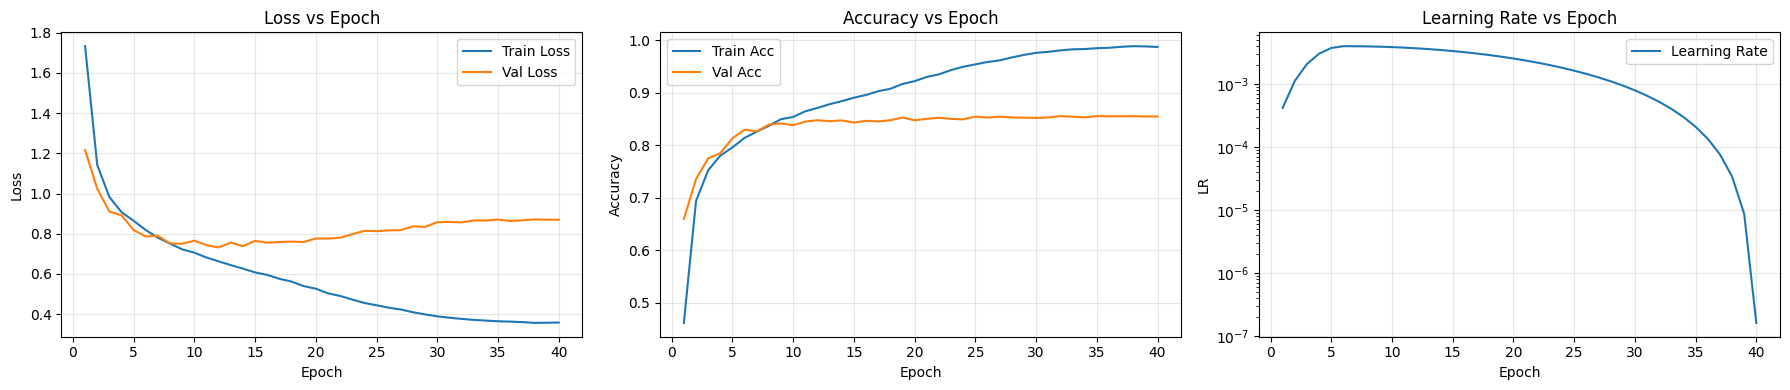

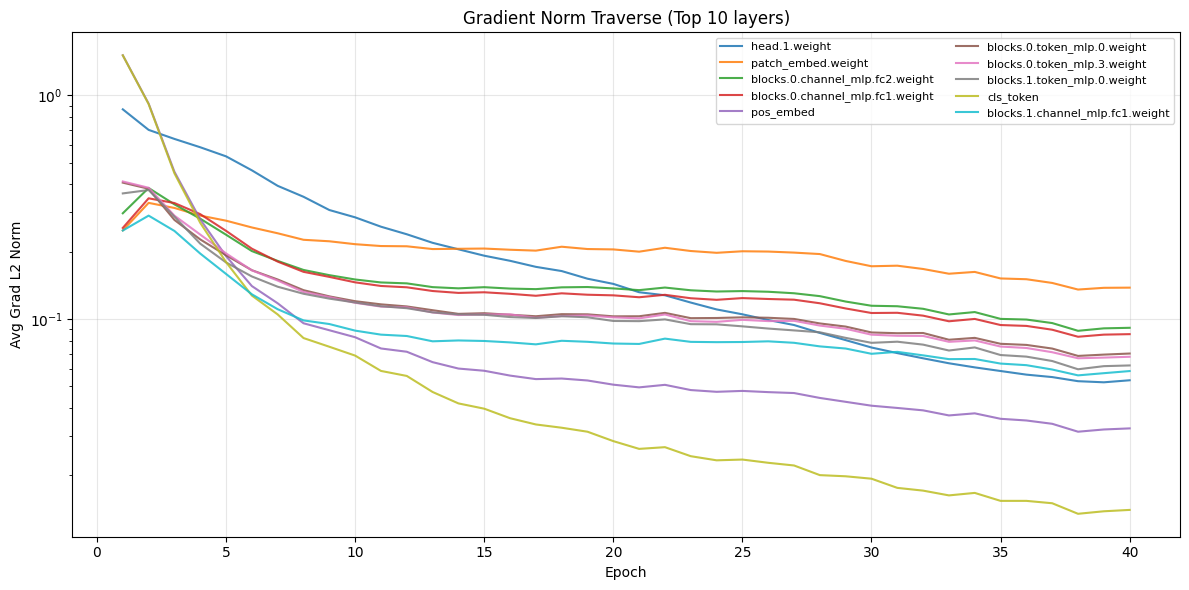

Validation accuracy: 0.8553


<Figure size 1200x1000 with 0 Axes>

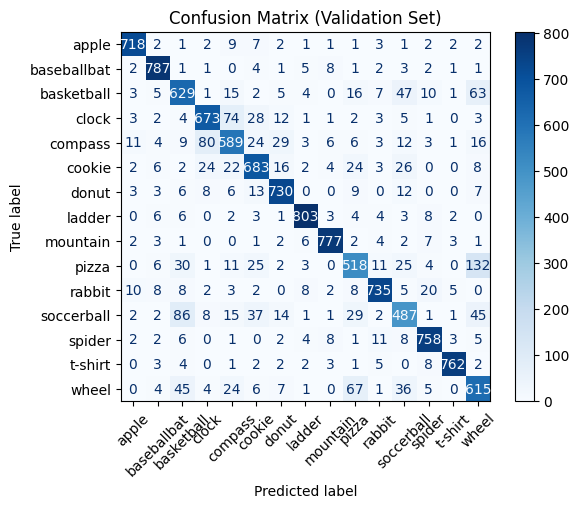


Classwise accuracy (low -> high):
soccerball      accuracy: 0.666
pizza           accuracy: 0.674
compass         accuracy: 0.740
wheel           accuracy: 0.755
basketball      accuracy: 0.778
clock           accuracy: 0.829
cookie          accuracy: 0.831
rabbit          accuracy: 0.901
donut           accuracy: 0.916
spider          accuracy: 0.935
ladder          accuracy: 0.950
apple           accuracy: 0.952
mountain        accuracy: 0.958
t-shirt         accuracy: 0.958
baseballbat     accuracy: 0.961

Running PatchMLP_v2_DEEP
Trainable parameters: 1082399
[PatchMLP_v2_DEEP] Epoch 01/40 | Train: loss 1.6499, acc 0.4878 | Val: loss 1.1477, acc 0.6932 | LR: 0.000365 | Best Val Acc: 0.6932 (ep 1)
[PatchMLP_v2_DEEP] Epoch 02/40 | Train: loss 1.0753, acc 0.7196 | Val: loss 0.9298, acc 0.7772 | LR: 0.000981 | Best Val Acc: 0.7772 (ep 2)
[PatchMLP_v2_DEEP] Epoch 03/40 | Train: loss 0.9387, acc 0.7698 | Val: loss 0.8752, acc 0.7953 | LR: 0.001821 | Best Val Acc: 0.7953 (ep 3)
[PatchMLP

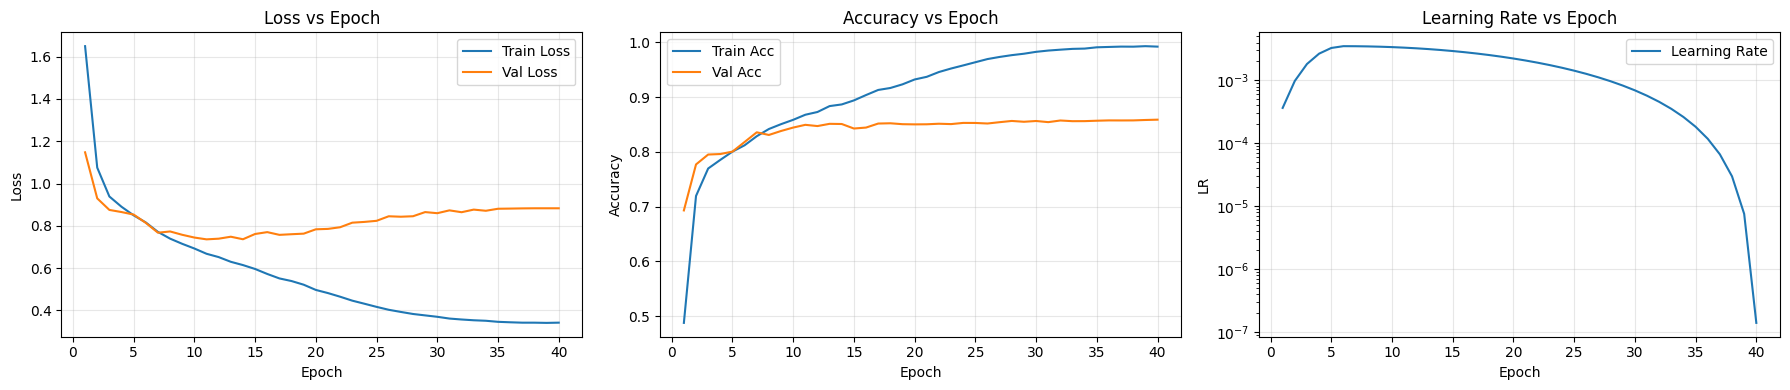

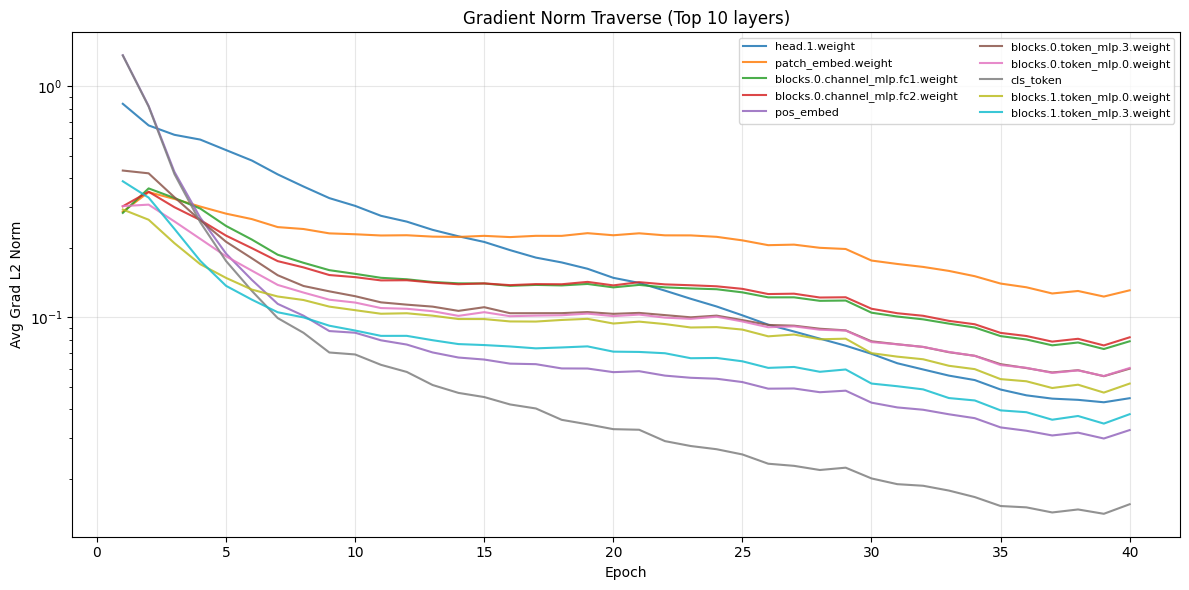

Validation accuracy: 0.8589


<Figure size 1200x1000 with 0 Axes>

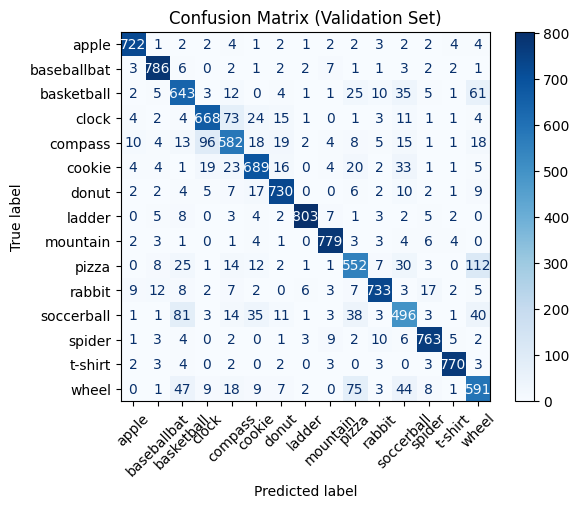


Classwise accuracy (low -> high):
soccerball      accuracy: 0.679
pizza           accuracy: 0.719
wheel           accuracy: 0.725
compass         accuracy: 0.731
basketball      accuracy: 0.796
clock           accuracy: 0.823
cookie          accuracy: 0.838
rabbit          accuracy: 0.898
donut           accuracy: 0.916
spider          accuracy: 0.941
ladder          accuracy: 0.950
apple           accuracy: 0.958
baseballbat     accuracy: 0.960
mountain        accuracy: 0.961
t-shirt         accuracy: 0.969

Running PatchMLP_v2_WIDE
Trainable parameters: 1002651
[PatchMLP_v2_WIDE] Epoch 01/40 | Train: loss 1.7078, acc 0.4703 | Val: loss 1.1971, acc 0.6748 | LR: 0.000313 | Best Val Acc: 0.6748 (ep 1)
[PatchMLP_v2_WIDE] Epoch 02/40 | Train: loss 1.1089, acc 0.7028 | Val: loss 0.9752, acc 0.7539 | LR: 0.000841 | Best Val Acc: 0.7539 (ep 2)
[PatchMLP_v2_WIDE] Epoch 03/40 | Train: loss 0.9564, acc 0.7613 | Val: loss 0.8804, acc 0.7948 | LR: 0.001561 | Best Val Acc: 0.7948 (ep 3)
[PatchMLP

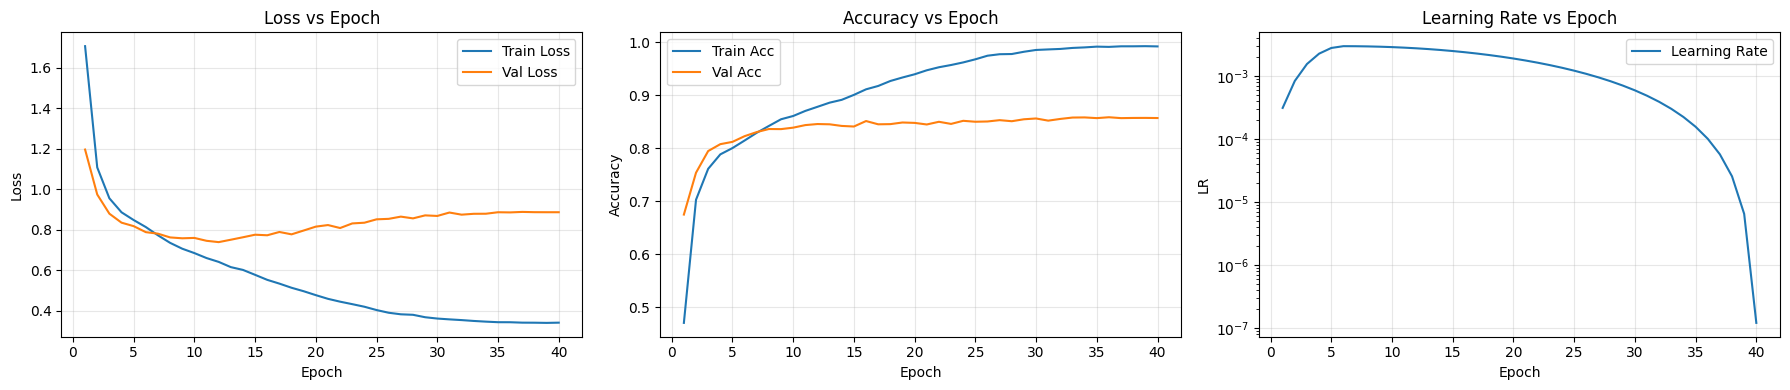

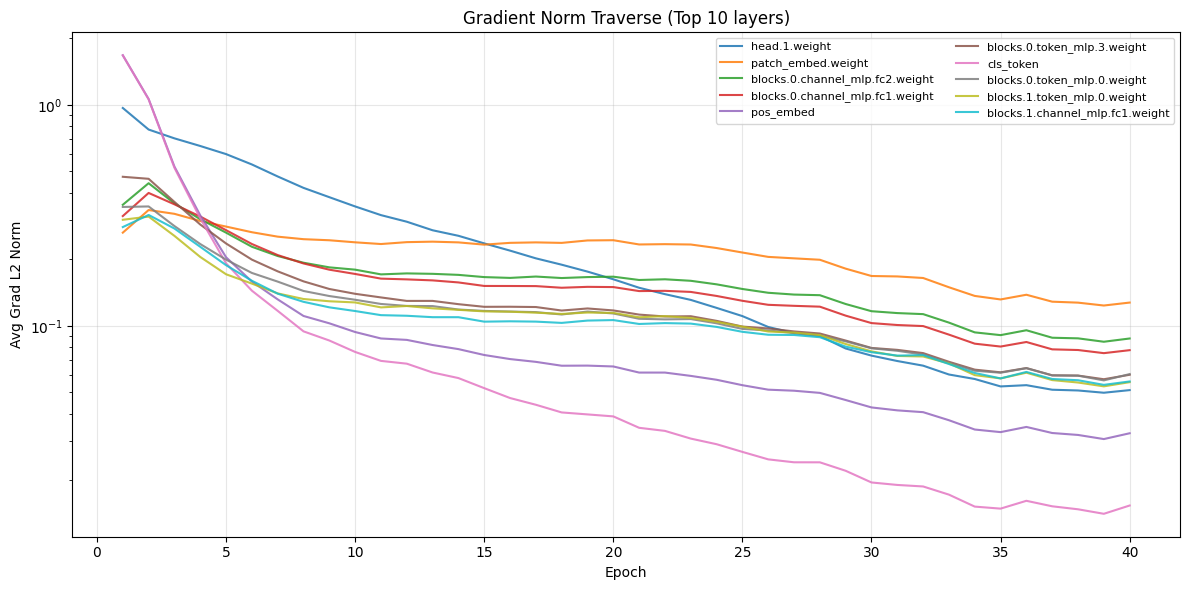

Validation accuracy: 0.8587


<Figure size 1200x1000 with 0 Axes>

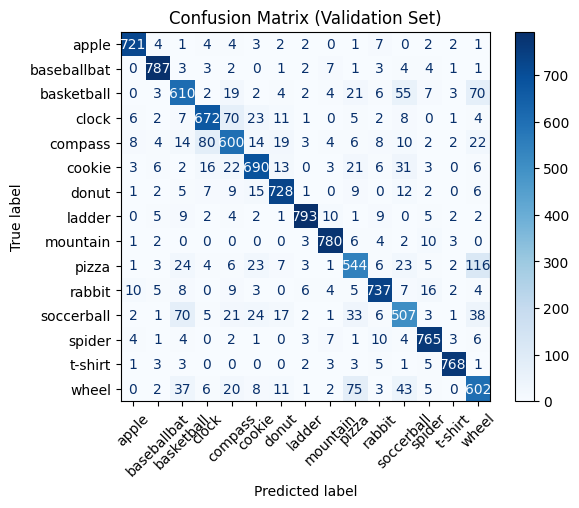


Classwise accuracy (low -> high):
soccerball      accuracy: 0.694
pizza           accuracy: 0.708
wheel           accuracy: 0.739
compass         accuracy: 0.754
basketball      accuracy: 0.755
clock           accuracy: 0.828
cookie          accuracy: 0.839
rabbit          accuracy: 0.903
donut           accuracy: 0.913
ladder          accuracy: 0.938
spider          accuracy: 0.943
apple           accuracy: 0.956
baseballbat     accuracy: 0.961
mountain        accuracy: 0.962
t-shirt         accuracy: 0.966

Running PatchMLP_v2_LIGHT
Trainable parameters: 384411
[PatchMLP_v2_LIGHT] Epoch 01/40 | Train: loss 1.7681, acc 0.4354 | Val: loss 1.1952, acc 0.6611 | LR: 0.000522 | Best Val Acc: 0.6611 (ep 1)
[PatchMLP_v2_LIGHT] Epoch 02/40 | Train: loss 1.1185, acc 0.6867 | Val: loss 0.9350, acc 0.7515 | LR: 0.001401 | Best Val Acc: 0.7515 (ep 2)
[PatchMLP_v2_LIGHT] Epoch 03/40 | Train: loss 0.9483, acc 0.7507 | Val: loss 0.8552, acc 0.7827 | LR: 0.002602 | Best Val Acc: 0.7827 (ep 3)
[Patch

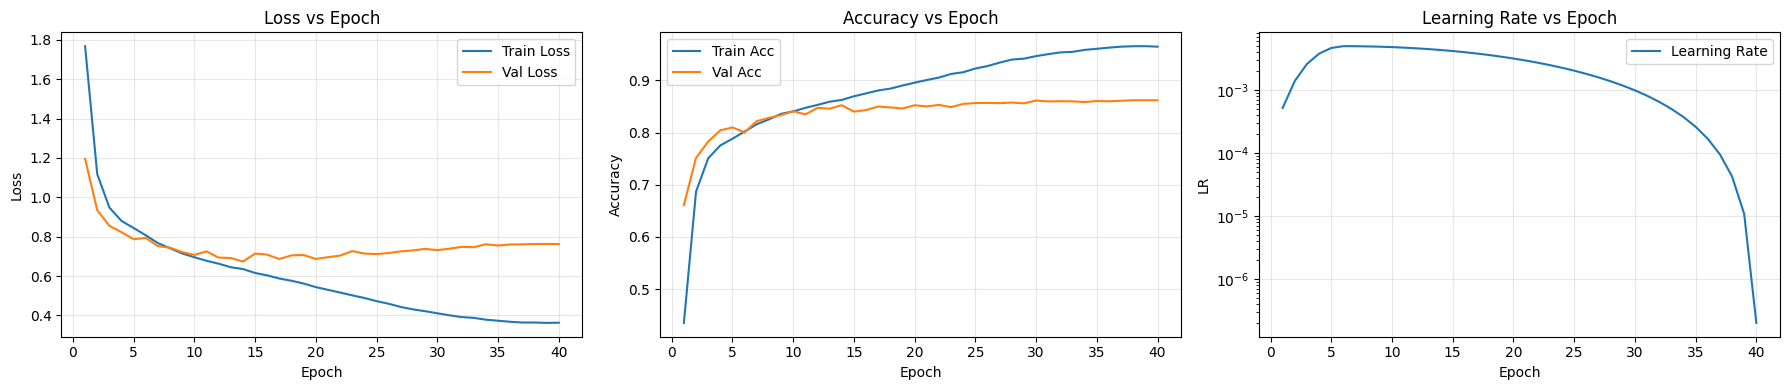

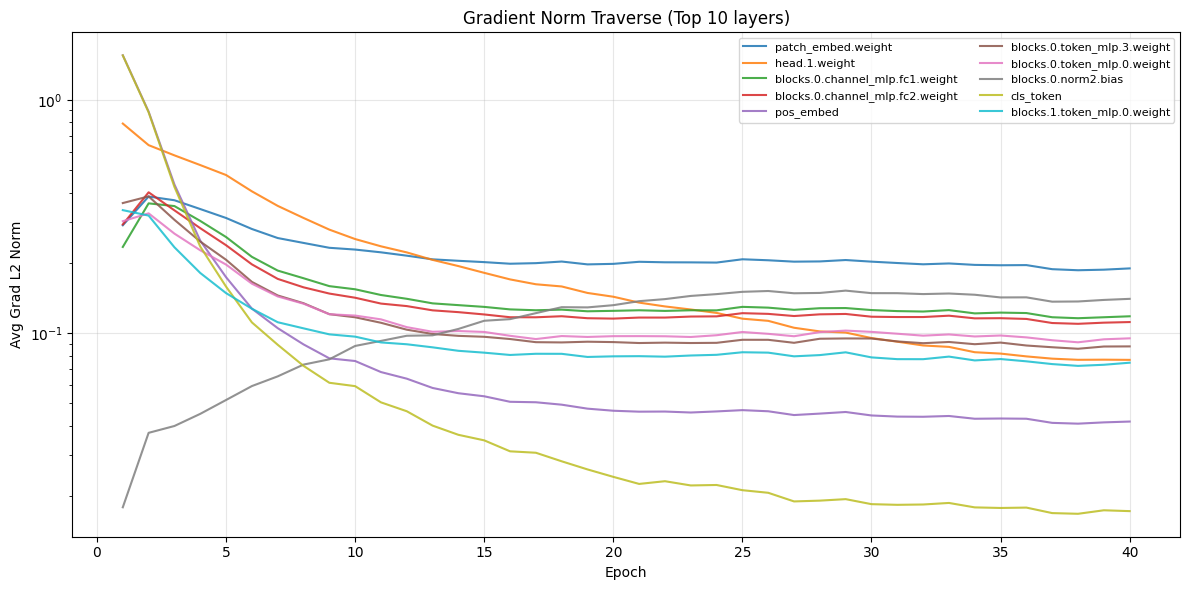

Validation accuracy: 0.8619


<Figure size 1200x1000 with 0 Axes>

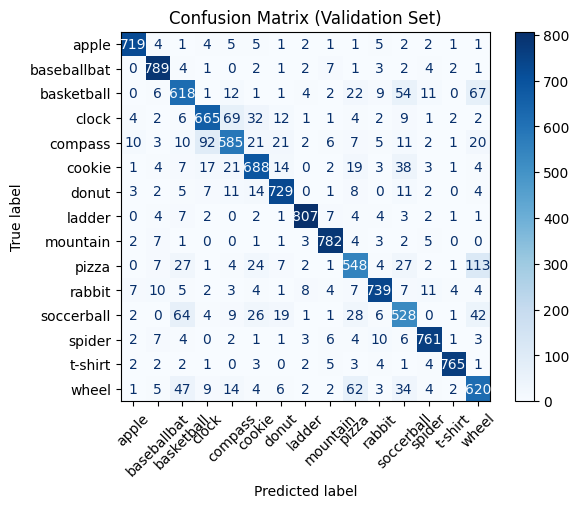


Classwise accuracy (low -> high):
pizza           accuracy: 0.714
soccerball      accuracy: 0.722
compass         accuracy: 0.735
wheel           accuracy: 0.761
basketball      accuracy: 0.765
clock           accuracy: 0.819
cookie          accuracy: 0.837
rabbit          accuracy: 0.906
donut           accuracy: 0.915
spider          accuracy: 0.938
apple           accuracy: 0.954
ladder          accuracy: 0.955
t-shirt         accuracy: 0.962
baseballbat     accuracy: 0.963
mountain        accuracy: 0.964

Completed training for variants:
- PatchMLP_v2_BASE: best val acc = 0.8553
- PatchMLP_v2_DEEP: best val acc = 0.8589
- PatchMLP_v2_WIDE: best val acc = 0.8587
- PatchMLP_v2_LIGHT: best val acc = 0.8619


In [26]:
# ==========================================
# TRAIN PATCHMLP VARIANTS
# ==========================================
patchmlp_results = {}

for variant in patchmlp_variants:
    tag = variant["tag"]
    patchmlp_results[tag] = run_patchmlp_experiment(
        tag=tag,
        model_kwargs=variant["model_kwargs"],
        max_lr=variant["max_lr"],
        weight_decay=variant["weight_decay"],
        label_smoothing=variant["label_smoothing"],
        grad_clip=5.0,
        epochs=EPOCHS,
        run_live_diagnostics=True,
        top_k_grad_layers=10,
    )

print("\nCompleted training for variants:")
for name, result in patchmlp_results.items():
    best_acc = result["history"].get("best_val_acc", np.max(result["history"]["val_acc"]))
    print(f"- {name}: best val acc = {best_acc:.4f}")

PatchMLP comparison summary (Training vs Validation):
PatchMLP_v2_LIGHT        | Params:   384,411 | Best Train/Val: 0.9655/0.8619 (best ep 38) | Final Train/Val: 0.9646/0.8618 | Generalization Gap: +0.1028 | Val Acc/MParam: 2.2422
PatchMLP_v2_DEEP         | Params: 1,082,399 | Best Train/Val: 0.9931/0.8589 (best ep 40) | Final Train/Val: 0.9923/0.8589 | Generalization Gap: +0.1334 | Val Acc/MParam: 0.7935
PatchMLP_v2_WIDE         | Params: 1,002,651 | Best Train/Val: 0.9929/0.8587 (best ep 36) | Final Train/Val: 0.9924/0.8572 | Generalization Gap: +0.1353 | Val Acc/MParam: 0.8564
PatchMLP_v2_BASE         | Params:   646,971 | Best Train/Val: 0.9883/0.8553 (best ep 35) | Final Train/Val: 0.9868/0.8547 | Generalization Gap: +0.1322 | Val Acc/MParam: 1.3221

Winner by best validation accuracy: PatchMLP_v2_LIGHT over PatchMLP_v2_DEEP (margin = 0.0030)


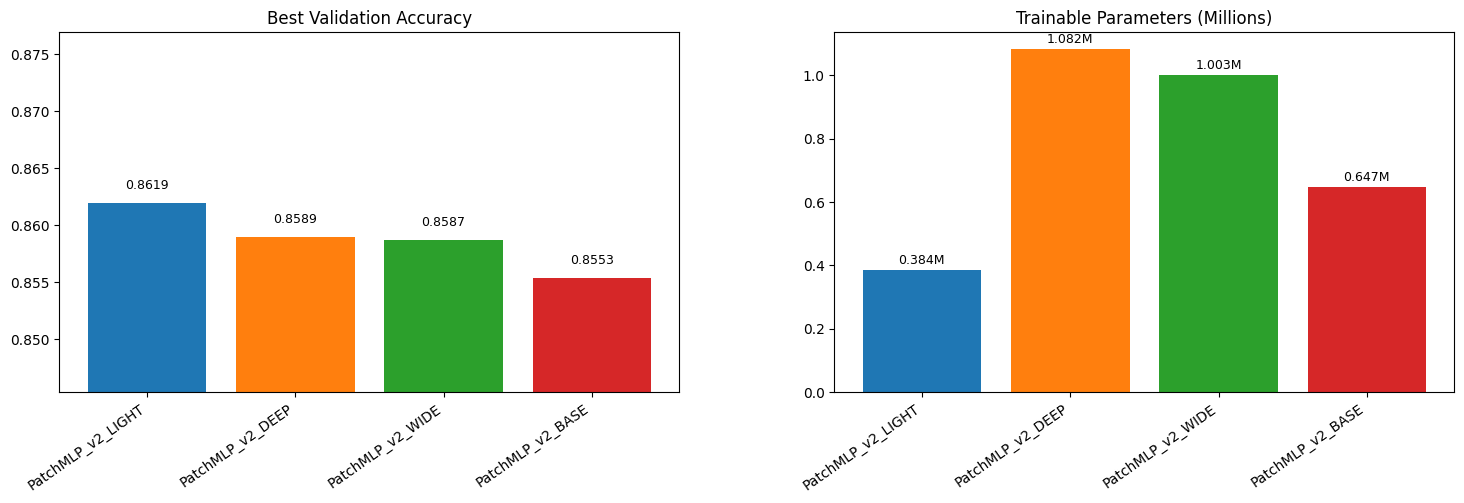

In [27]:
# ==========================================
# MODEL COMPARISON + ANALYSIS
# ==========================================
if "patchmlp_results" not in globals() or not patchmlp_results:
    raise RuntimeError("Run training cell first to populate patchmlp_results.")

comparison = []
for model_name, result in patchmlp_results.items():
    history = result["history"]
    params_m = result["params"] / 1_000_000

    comparison.append(
        {
            "Model": model_name,
            "Params": int(result["params"]),
            "Best Epoch": int(history.get("best_epoch", int(np.argmax(history["val_acc"]) + 1))),
            "Best Train Acc": float(np.max(history["train_acc"])),
            "Best Val Acc": float(history.get("best_val_acc", np.max(history["val_acc"]))),
            "Final Train Acc": float(history["train_acc"][-1]),
            "Final Val Acc": float(history["val_acc"][-1]),
            "Final Val Loss": float(history["val_loss"][-1]),
            "Generalization Gap": float(history["train_acc"][-1] - history["val_acc"][-1]),
            "Val Acc / MParam": float(history.get("best_val_acc", np.max(history["val_acc"])) / params_m),
            "Best Model File": result.get("checkpoint", ""),
        }
    )

comparison_sorted = sorted(comparison, key=lambda row: row["Best Val Acc"], reverse=True)

print("PatchMLP comparison summary (Training vs Validation):")
for row in comparison_sorted:
    print(
        f"{row['Model']:24s} | "
        f"Params: {row['Params']:>9,} | "
        f"Best Train/Val: {row['Best Train Acc']:.4f}/{row['Best Val Acc']:.4f} (best ep {row['Best Epoch']}) | "
        f"Final Train/Val: {row['Final Train Acc']:.4f}/{row['Final Val Acc']:.4f} | "
        f"Generalization Gap: {row['Generalization Gap']:+.4f} | "
        f"Val Acc/MParam: {row['Val Acc / MParam']:.4f}"
    )

if len(comparison_sorted) >= 2:
    winner = comparison_sorted[0]["Model"]
    runner_up = comparison_sorted[1]["Model"]
    margin = comparison_sorted[0]["Best Val Acc"] - comparison_sorted[1]["Best Val Acc"]
    print(f"\nWinner by best validation accuracy: {winner} over {runner_up} (margin = {margin:.4f})")

models = [row["Model"] for row in comparison_sorted]
best_val_acc = [row["Best Val Acc"] for row in comparison_sorted]
params_millions = [row["Params"] / 1_000_000 for row in comparison_sorted]
plot_colors = [plt.cm.tab10(i) for i in range(len(comparison_sorted))]
positions = np.arange(len(models))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].bar(positions, best_val_acc, color=plot_colors)
axes[0].set_title("Best Validation Accuracy")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(models, rotation=35, ha="right")
axes[0].set_ylim(min(best_val_acc) - 0.01, max(best_val_acc) + 0.015)
for index, value in enumerate(best_val_acc):
    axes[0].text(index, value + 0.001, f"{value:.4f}", ha="center", va="bottom", fontsize=9)

axes[1].bar(positions, params_millions, color=plot_colors)
axes[1].set_title("Trainable Parameters (Millions)")
axes[1].set_xticks(positions)
axes[1].set_xticklabels(models, rotation=35, ha="right")
for index, value in enumerate(params_millions):
    axes[1].text(index, value + 0.01, f"{value:.3f}M", ha="center", va="bottom", fontsize=9)

fig.subplots_adjust(bottom=0.28, wspace=0.25)
plt.show()

In [28]:
# ==========================================
# TEST INFERENCE + SUBMISSION EXPORT (ALL MODELS)
# ==========================================
from torch.utils.data import DataLoader
import re

if "patchmlp_results" not in globals() or not patchmlp_results:
    raise RuntimeError("No trained PatchMLP results found. Run training cell first.")

results_dir = globals().get("RESULTS_DIR", "./results")
os.makedirs(results_dir, exist_ok=True)

def sanitize_model_name(model_name):
    return re.sub(r"[^0-9A-Za-z_]+", "_", model_name)

@torch.no_grad()
def run_test_inference(model, test_loader):
    model.eval()
    all_test_preds = []

    for batch in test_loader:
        images = batch[0] if isinstance(batch, (tuple, list)) else batch
        images = normalize_batch(images).to(DEVICE)
        logits = model(images)
        preds = torch.argmax(logits, dim=1)
        all_test_preds.append(preds.cpu().numpy())

    return np.concatenate(all_test_preds).astype(int)

print(f"Loading test data from {TEST_FILE}...")
test_dataset = QuickDrawDataset(TEST_FILE, mode="test")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

exported_files = {}
for model_name, result in patchmlp_results.items():
    model = result["model"]

    checkpoint_path = result.get("checkpoint", "")
    if checkpoint_path and os.path.exists(checkpoint_path):
        state_dict = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(state_dict)
        print(f"[{model_name}] Loaded checkpoint: {checkpoint_path}")
    else:
        print(f"[{model_name}] Checkpoint not found; using in-memory model weights.")

    test_preds = run_test_inference(model, test_loader)

    safe_name = sanitize_model_name(model_name)
    output_file = os.path.join(results_dir, f"submission_{safe_name}.txt")
    with open(output_file, "w") as f:
        f.write(",".join(map(str, test_preds.tolist())))

    exported_files[model_name] = output_file
    print(f"[{model_name}] Exported {len(test_preds)} predictions -> {output_file}")

if "comparison_sorted" in globals() and comparison_sorted:
    best_model_name = comparison_sorted[0]["Model"]
else:
    best_model_name = max(
        patchmlp_results.keys(),
        key=lambda name: patchmlp_results[name]["history"].get(
            "best_val_acc",
            float(np.max(patchmlp_results[name]["history"]["val_acc"])),
        ),
    )

best_output_file = exported_files.get(best_model_name)
if best_output_file and os.path.exists(best_output_file):
    final_submission_file = os.path.join(results_dir, "submission.txt")
    with open(best_output_file, "r") as src, open(final_submission_file, "w") as dst:
        dst.write(src.read())
    print(f"\nUpdated {final_submission_file} from best model: {best_model_name}")

print("\nAll exported files:")
for model_name, file_name in exported_files.items():
    print(f"- {model_name}: {file_name}")

Loading test data from /content/drive/MyDrive/Asg2/processed_data/quickdraw_test.npz...
Loading test data from /content/drive/MyDrive/Asg2/processed_data/quickdraw_test.npz...
Loaded 15000 test images.
[PatchMLP_v2_BASE] Loaded checkpoint: /content/drive/MyDrive/Asg2/checkpoints/best_patchmlp_v2_base.pth
[PatchMLP_v2_BASE] Exported 15000 predictions -> /content/drive/MyDrive//Asg2/results/submission_PatchMLP_v2_BASE.txt
[PatchMLP_v2_DEEP] Loaded checkpoint: /content/drive/MyDrive/Asg2/checkpoints/best_patchmlp_v2_deep.pth
[PatchMLP_v2_DEEP] Exported 15000 predictions -> /content/drive/MyDrive//Asg2/results/submission_PatchMLP_v2_DEEP.txt
[PatchMLP_v2_WIDE] Loaded checkpoint: /content/drive/MyDrive/Asg2/checkpoints/best_patchmlp_v2_wide.pth
[PatchMLP_v2_WIDE] Exported 15000 predictions -> /content/drive/MyDrive//Asg2/results/submission_PatchMLP_v2_WIDE.txt
[PatchMLP_v2_LIGHT] Loaded checkpoint: /content/drive/MyDrive/Asg2/checkpoints/best_patchmlp_v2_light.pth
[PatchMLP_v2_LIGHT] Export